# Profile Generation Tests

Objective: exercise the attack-profile generation pipeline in one notebook, with emphasis on the new v3 target-zone data path for VAE training.

Use this notebook to:
- generate a small in-memory `random_zones` sample
- inspect target-zone, approach-side, and label coverage
- verify spawn clearance and accessible-envelope placement
- compare multiple convoy layouts
- optionally write a JSONL dataset after the checks look sane


## Workflow

1. Configure sample sizes and seeds.
2. Generate v3 `random_zones` records in memory.
3. Audit distribution coverage and geometry constraints.
4. Plot convoy, target points, and U-boat spawns when plotting is available.
5. Run a multi-layout smoke check.
6. Optionally export JSONL for VAE experiments.

This notebook intentionally does not train the VAE. The goal is to decide whether the data manifold is worth training on.


In [1]:
#Imports
from __future__ import annotations
from collections import Counter
import json
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.audit_attack_profile_dataset import flatten_dataset_records, summarize_flat_rows
from experiments.generate_attack_profile_scaffold import (
    MIN_SPAWN_CLEARANCE_M,
    generate_attack_profile_scaffolds,
    render_profiles_as_jsonl,)
from convoy_sim.target_zones import convoy_frame_and_envelope
from convoy_sim.profile_generation_viz import (
    FIXED_X_LIMITS,
    U_BOAT_COLOR,
    U_BOAT_EDGE,
    apply_limits,
    combined_limits,
    simple_ship_polygons,
    style_ax,
)
from scenarios.convoy_profiles import get_convoy_layout_profile, list_convoy_layout_profiles

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config

Start with `COUNT = 512` for a fast but meaningful smoke test. Increase to `5000+` only after the small run passes.


In [3]:
MODE = "random_zones"
CONVOY_PROFILE = "convoy_layout_1"
COUNT = 512
SEED = 1945
START_INDEX = 1

# Optional export. Leave disabled until the checks below look good.
WRITE_JSONL = False
EXPORT_PATH = PROJECT_ROOT / "data/attack_profiles/synthetic/train_random_zones_v3.jsonl"

EXPECTED_HIT_FRACTION = 0.75
MIN_EXPECTED_ZONE_KINDS = 5
MIN_EXPECTED_APPROACH_SIDES = 8


## Helpers

These helpers keep repeated generation and display code compact.


In [4]:
def build_records(*, mode: str, convoy_profile: str, count: int, seed: int, start_index: int = 1) -> list[dict]:
    profiles, audit_rows = generate_attack_profile_scaffolds(
        mode=mode,
        convoy_profile=convoy_profile,
        count=count,
        seed=seed,
        start_index=start_index,
    )
    rendered = render_profiles_as_jsonl(
        profiles,
        audit_rows=audit_rows,
        seed=seed,
        convoy_profile=convoy_profile,
        accepted_labels=("credible_hit_threat", "credible_near_miss"),
        mode=mode,
    )
    return [json.loads(line) for line in rendered.splitlines() if line.strip()]


def value_counts(rows: list[dict], column: str) -> dict[str, int]:
    return dict(Counter(str(row.get(column, "")) for row in rows if str(row.get(column, ""))))


def count_table(counts: dict[str, int]) -> pd.DataFrame:
    return pd.DataFrame([{"value": key, "count": counts[key]} for key in sorted(counts)])


## Generate Records

This uses the Python API directly, then renders and reloads JSONL so the notebook tests the same schema used by saved datasets.


In [5]:
start = time.perf_counter()
records = build_records(
    mode=MODE,
    convoy_profile=CONVOY_PROFILE,
    count=int(COUNT),
    seed=int(SEED),
    start_index=int(START_INDEX),
)
elapsed = time.perf_counter() - start

print(f"Generated {len(records):,} records in {elapsed:.2f}s")
records[0]


Generated 512 records in 0.22s


{'profile': {'profile_id': 'Z000001',
  'name': 'zone_dataset_000001_trailing_column_port_credible_hit_threat',
  'weight': 1.0,
  'mode': 'fan',
  'u_pos': [-1156.309148648606, 4732.0199999999995],
  'n': 4,
  'speed': 15.4333,
  'max_run_time': 486.0,
  'base_bearing_rad': -1.549009797359659,
  'spread_doctrine': 'uniform_divergent',
  'spread_rad': 0.09599310885968812,
  'per_torpedo_heading_offsets_rad': [],
  'launch_delay_s': 0.5,
  'salvo_interval_s': 3.0,
  'u_boat_mode': 'moving',
  'u_boat_initial_heading_rad': -1.549009797359659,
  'u_boat_initial_speed_mps': 1.0,
  'sub_length_m': 67.0,
  'sub_beam_m': 6.5,
  'launch_from': 'bow',
  'max_bow_offset_deg': 15.0,
  'gyro_straight_run_m': 10.0},
 'audit': {'profile_id': 'Z000001',
  'name': 'zone_dataset_000001_trailing_column_port_credible_hit_threat',
  'mode': 'fan',
  'u_pos_x': -1156.309148648606,
  'u_pos_y': 4732.0199999999995,
  'range_to_centroid_m': 4871.248723648636,
  'centroid_bearing_rad': -1.3311343500984247,
  '

## Flatten And Summarize

The flat rows mirror `experiments.audit_attack_profile_dataset` outputs, so these views should match the CSV audit if you later write files.


In [6]:
flat_rows = flatten_dataset_records(records)
summary = summarize_flat_rows(flat_rows)

summary_view = {
    "profile_count": summary["profile_count"],
    "labels": summary["labels"],
    "target_zone_kinds": summary.get("target_zone_kinds", {}),
    "approach_sides": summary.get("approach_sides", {}),
    "range_to_target_m": summary.get("range_to_target_m", {}),
    "severity": summary.get("severity", {}),
}
summary_view


{'profile_count': 512,
 'labels': {'credible_hit_threat': 384, 'credible_near_miss': 128},
 'target_zone_kinds': {'trailing_column': 89,
  'interior': 115,
  'port_edge': 106,
  'starboard_edge': 102,
  'lead_column': 100},
 'approach_sides': {'port': 57,
  'astern': 70,
  'ahead': 63,
  'starboard': 53,
  'starboard_forward_quarter': 71,
  'port_forward_quarter': 79,
  'starboard_aft_quarter': 55,
  'port_aft_quarter': 64},
 'range_to_target_m': {'mean': 4616.643424731327,
  'min': 951.3131181093938,
  'max': 9261.267575597229},
 'severity': {'mean': 5.0152126564594415,
  'min': 0.00017721237324156024,
  'max': 13.114949988464579}}

## Coverage Checks

These assertions are intentionally blunt. If one fails, inspect the tables/plots before changing thresholds.


In [7]:
label_counts = value_counts(flat_rows, "suggested_label")
hit_count = int(label_counts.get("credible_hit_threat", 0))
hit_fraction = hit_count / max(len(flat_rows), 1)
zone_kind_count = len(value_counts(flat_rows, "target_zone_kind"))
approach_side_count = len(value_counts(flat_rows, "approach_side"))

checks = {
    "has_expected_count": len(flat_rows) == COUNT,
    "hit_fraction": hit_fraction,
    "has_expected_zone_kinds": zone_kind_count >= MIN_EXPECTED_ZONE_KINDS,
    "has_expected_approach_sides": approach_side_count >= MIN_EXPECTED_APPROACH_SIDES,
    "no_implausible_labels": set(label_counts) <= {"credible_hit_threat", "credible_near_miss"},
    "all_have_intent": all("intent" in record for record in records),
}
checks


{'has_expected_count': True,
 'hit_fraction': 0.75,
 'has_expected_zone_kinds': True,
 'has_expected_approach_sides': True,
 'no_implausible_labels': True,
 'all_have_intent': True}

In [8]:
assert checks["has_expected_count"]
assert abs(checks["hit_fraction"] - EXPECTED_HIT_FRACTION) <= 0.02
assert checks["has_expected_zone_kinds"]
assert checks["has_expected_approach_sides"]
assert checks["no_implausible_labels"]
assert checks["all_have_intent"]


## Distribution Tables

Use these to quickly spot collapse before looking at plots.


In [9]:
distribution_tables = {
    "labels": count_table(value_counts(flat_rows, "suggested_label")),
    "target_zone_kind": count_table(value_counts(flat_rows, "target_zone_kind")),
    "approach_side": count_table(value_counts(flat_rows, "approach_side")),
    "approach_lane": count_table(value_counts(flat_rows, "approach_lane")),
}
distribution_tables["target_zone_kind"]


,value,count
0,interior,115
1,lead_column,100
2,port_edge,106
3,starboard_edge,102
4,trailing_column,89


In [10]:
distribution_tables["approach_side"]


,value,count
0,ahead,63
1,astern,70
2,port,57
3,port_aft_quarter,64
4,port_forward_quarter,79
5,starboard,53
6,starboard_aft_quarter,55
7,starboard_forward_quarter,71


## Distribution Plots

Look for obvious collapse. For v3 training data, target-zone kinds and approach sides should both be reasonably populated.


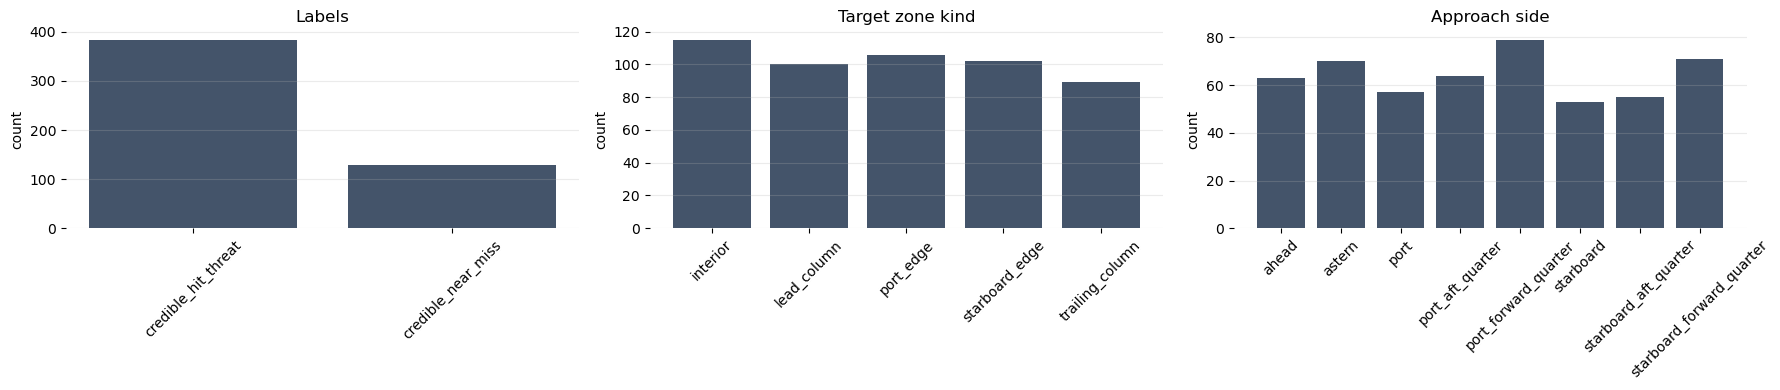

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor="white")
plot_specs = [
    ("suggested_label", "Labels"),
    ("target_zone_kind", "Target zone kind"),
    ("approach_side", "Approach side"),
]
for ax, (column, title) in zip(axes, plot_specs):
    counts = value_counts(flat_rows, column)
    labels = sorted(counts)
    ax.bar(labels, [counts[label] for label in labels], color="#44546a")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


## Geometry Checks

This verifies two practical constraints:
- U-boat spawn is at least `MIN_SPAWN_CLEARANCE_M` from every ship center.
- Spawn is outside the convoy local envelope on at least one access axis.


In [12]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
frame, envelope, _local_positions = convoy_frame_and_envelope(ships)
ship_positions = np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float)

spawn_xy = np.asarray([[float(row["u_pos_x"]), float(row["u_pos_y"])] for row in flat_rows], dtype=float)
clearances = np.min(np.linalg.norm(spawn_xy[:, None, :] - ship_positions[None, :, :], axis=2), axis=1)
spawn_local = np.asarray([frame.world_to_local(point) for point in spawn_xy], dtype=float)
outside_envelope = (
    (spawn_local[:, 0] < envelope.min_x)
    | (spawn_local[:, 0] > envelope.max_x)
    | (spawn_local[:, 1] < envelope.min_y)
    | (spawn_local[:, 1] > envelope.max_y)
)

checked_rows = []
for idx, row in enumerate(flat_rows):
    enriched = dict(row)
    enriched["clearance_m"] = float(clearances[idx])
    enriched["spawn_local_x"] = float(spawn_local[idx, 0])
    enriched["spawn_local_y"] = float(spawn_local[idx, 1])
    enriched["outside_envelope"] = bool(outside_envelope[idx])
    checked_rows.append(enriched)

geometry_summary = {
    "min_clearance_m": float(clearances.min()),
    "clearance_failures": int((clearances < MIN_SPAWN_CLEARANCE_M).sum()),
    "outside_envelope_failures": int((~outside_envelope).sum()),
    "min_range_to_target_m": float(min(float(row["range_to_target_m"]) for row in flat_rows)),
    "max_range_to_target_m": float(max(float(row["range_to_target_m"]) for row in flat_rows)),
}
geometry_summary


{'min_clearance_m': 400.00004741524674,
 'clearance_failures': 0,
 'outside_envelope_failures': 0,
 'min_range_to_target_m': 951.3131181093938,
 'max_range_to_target_m': 9261.267575597229}

In [13]:
assert geometry_summary["clearance_failures"] == 0
assert geometry_summary["outside_envelope_failures"] == 0


## Geometry Plot

Black squares are ship centers, colored dots are U-boat spawn points, and small x-marks are intended target points.


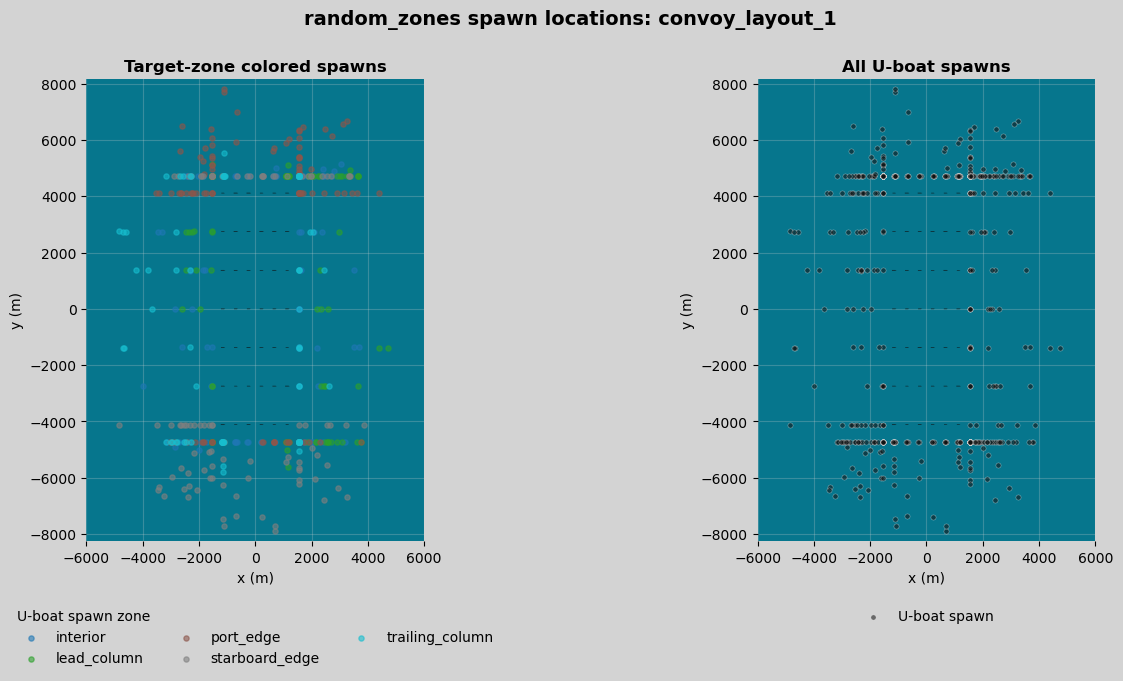

In [14]:
spawn_df = pd.DataFrame(flat_rows)
spawn_df["u_pos"] = spawn_df[["u_pos_x", "u_pos_y"]].values.tolist()
spawn_points = np.vstack(spawn_df["u_pos"].to_list()) if len(spawn_df) else None
ships_spawn_plot = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
shared_limits = combined_limits(ships_spawn_plot, extra_points=spawn_points, pad=350.0)
zone_values = sorted(spawn_df["target_zone_kind"].unique())
zone_colors = dict(zip(zone_values, plt.cm.tab10(np.linspace(0, 1, len(zone_values)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="lightgrey")

style_ax(axes[0], "Target-zone colored spawns")
simple_ship_polygons(axes[0], ships_spawn_plot)
for zone in zone_values:
    zone_xy = np.vstack(spawn_df.loc[spawn_df["target_zone_kind"] == zone, "u_pos"].to_list())
    axes[0].scatter(
        zone_xy[:, 0],
        zone_xy[:, 1],
        c=[zone_colors[zone]],
        s=14,
        alpha=0.58,
        zorder=2,
        label=zone,
    )
apply_limits(axes[0], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
leg = axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=3, frameon=False, title="U-boat spawn zone")
if leg is not None:
    leg._legend_box.align = "left"

style_ax(axes[1], "All U-boat spawns")
simple_ship_polygons(axes[1], ships_spawn_plot)
if len(spawn_df):
    spawn_xy = np.vstack(spawn_df["u_pos"].to_list())
    axes[1].scatter(
        spawn_xy[:, 0],
        spawn_xy[:, 1],
        c=U_BOAT_COLOR,
        edgecolors=U_BOAT_EDGE,
        linewidths=0.35,
        s=14,
        alpha=0.55,
        zorder=2,
        label="U-boat spawn",
    )
apply_limits(axes[1], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=1, frameon=False)

fig.suptitle(f"{MODE} spawn locations: {CONVOY_PROFILE}", fontsize=14, weight="bold")
fig.subplots_adjust(bottom=0.22, top=0.88, wspace=0.18)
plt.show()


## Worst Rows

Near-misses should dominate the highest-error rows. If hit threats appear here with high error, inspect spread and target geometry.


In [15]:
worst_cols = [
    "profile_id",
    "suggested_label",
    "intended_label",
    "target_zone_kind",
    "approach_side",
    "range_to_target_m",
    "bearing_error_deg",
    "spread_deg",
    "severity",
]
worst_rows = [
    {key: row[key] for key in worst_cols}
    for row in sorted(checked_rows, key=lambda item: float(item["severity"]), reverse=True)[:20]
]
pd.DataFrame(worst_rows)


,profile_id,suggested_label,intended_label,target_zone_kind,approach_side,range_to_target_m,bearing_error_deg,spread_deg,severity
0,Z000169,credible_near_miss,credible_near_miss,starboard_edge,port_forward_quarter,8956.608854,10.929125,16.0,13.114950
1,Z000226,credible_near_miss,credible_near_miss,trailing_column,port,7477.949463,10.860800,16.0,13.032960
2,Z000294,credible_near_miss,credible_near_miss,interior,starboard_forward_quarter,2969.780470,10.829004,16.0,12.994805
3,Z000432,credible_near_miss,credible_near_miss,interior,port_forward_quarter,6329.073060,10.590337,16.0,12.708405
4,Z000305,credible_near_miss,credible_near_miss,trailing_column,starboard_aft_quarter,6250.835178,10.580983,16.0,12.697180
5,Z000421,credible_near_miss,credible_near_miss,starboard_edge,port,8847.501548,10.544698,16.0,12.653638
6,Z000377,credible_near_miss,credible_near_miss,port_edge,port,1596.244339,10.528920,16.0,12.634705
7,Z000206,credible_near_miss,credible_near_miss,starboard_edge,starboard,2532.288391,10.474244,16.0,12.569092
8,Z000050,credible_near_miss,credible_near_miss,trailing_column,port_aft_quarter,2811.727645,10.462279,16.0,12.554735
9,Z000011,credible_near_miss,credible_near_miss,starboard_edge,starboard,1294.186945,10.450995,16.0,12.541194


## Multi-Layout Smoke Test

This checks that v3 generation is not hardwired to one convoy profile.


In [16]:
layout_rows = []
for layout_name in list_convoy_layout_profiles():
    layout_count = 128 if layout_name == "small_demo" else 256
    start = time.perf_counter()
    layout_records = build_records(
        mode=MODE,
        convoy_profile=layout_name,
        count=layout_count,
        seed=SEED,
        start_index=START_INDEX,
    )
    layout_flat = flatten_dataset_records(layout_records)
    layout_rows.append(
        {
            "convoy_profile": layout_name,
            "count": len(layout_flat),
            "seconds": round(time.perf_counter() - start, 3),
            "labels": value_counts(layout_flat, "suggested_label"),
            "zone_kinds": len(value_counts(layout_flat, "target_zone_kind")),
            "approach_sides": len(value_counts(layout_flat, "approach_side")),
            "min_range_to_target_m": float(min(float(row["range_to_target_m"]) for row in layout_flat)),
            "max_range_to_target_m": float(max(float(row["range_to_target_m"]) for row in layout_flat)),
        }
    )

pd.DataFrame(layout_rows)


,convoy_profile,count,seconds,labels,zone_kinds,approach_sides,min_range_to_target_m,max_range_to_target_m
0,small_demo,128,0.057,"{'credible_hit_threat': 96, 'credible_near_mis...",5,8,952.349463,3796.835808
1,convoy_layout_1,256,0.114,"{'credible_hit_threat': 192, 'credible_near_mi...",5,8,951.313118,9261.267576
2,convoy_layout_2,256,0.135,"{'credible_hit_threat': 192, 'credible_near_mi...",5,8,1107.415004,7631.535467
3,convoy_layout_mixed_1,256,0.163,"{'credible_hit_threat': 192, 'credible_near_mi...",5,8,951.313118,9265.894785


In [17]:
assert all(row["count"] > 0 for row in layout_rows)
assert all(row["zone_kinds"] >= 1 for row in layout_rows)
assert all(row["approach_sides"] >= 4 for row in layout_rows)


## Optional Export

Set `WRITE_JSONL = True` in the config cell, rerun from the top, and this cell will write the currently inspected records.


In [18]:
if WRITE_JSONL:
    EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    EXPORT_PATH.write_text("".join(json.dumps(record) + "\n" for record in records), encoding="utf-8")
    print(f"Wrote {len(records):,} records to {EXPORT_PATH}")
else:
    print("WRITE_JSONL is set to False; no file written.")



WRITE_JSONL is set to False; no file written.


## Notes For Follow-Up

Good signs:
- label mix stays close to 75/25
- target-zone kinds are populated without obvious collapse
- all approach sides appear
- no clearance or envelope failures
- target range distribution is broad rather than snapped to centroid bands

If these pass, the next engineering step is to update VAE preprocessing to consume target-relative/local features from the v3 schema.
